# Logistic Regression to predict 30-day readmission risk for diabetes patients

## Objective
This notebook implements logistic regression as a baseline to predict readmission risk for hospital readmission for diabetes patient

## Methodology






In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model building and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                   validation_curve, learning_curve, KFold)
from sklearn.metrics import (accuracy_score, classification_report,
                           confusion_matrix, roc_curve, precision_recall_curve,
                           auc, average_precision_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
pd.set_option('display.max_columns', None)

# Load into pandas
df = pd.read_csv('./diabetes_data.csv')

# Load pre-processed data
pre_processed_df = pd.read_csv('./preprocessed_data.csv')
 

print(df.shape)
print(df.columns)

print(pre_processed_df.shape)
print(pre_processed_df.columns)

(101766, 47)
Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')
(70431, 30)
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id'

/var/folders/2v/6l55gdf95zg32nnx7f894kd00000gn/T/ipykernel_1326/1615251241.py:4: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./diabetes_data.csv')


Feature engineering- (not much help)

In [ ]:
# Interaction features
# pre_processed_df['meds_times_er'] = pre_processed_df['num_medications'] * pre_processed_df['number_emergency']
# pre_processed_df['hosp_times_diag'] = pre_processed_df['time_in_hospital'] * pre_processed_df['number_diagnoses']

# # Abnormal test results
# pre_processed_df['abnormal_glucose'] = (pre_processed_df['max_glu_serum'] == '>300').astype(int)
# pre_processed_df['abnormal_A1C'] = (pre_processed_df['A1Cresult'] == '>8').astype(int)

# # Log transformation (if not already done)
# pre_processed_dfs['log_num_meds'] = np.log1p(pre_processed_df['num_medications'])

In [ ]:
# #re-categorise readmitted into readmitted within 30 days (1) or no readmission (0)
# readmitted_mapping = {'NO':0, '>30':0, '<30':1}
# diabetes['readmitted_map'] = diabetes['readmitted'].map(readmitted_mapping)

# #drop encounter_id, patient_nbr
# diabetes = diabetes.drop(['encounter_id','patient_nbr'],axis =1)

# #re-map race ("caucasian": 0, "africanamerican": 1, "hispanic": 2, "Asian": 3, "Other": 4)
# race_mapping = {"Caucasian": 0, "AfricanAmerican": 1, "Hispanic": 2, "Asian": 3, "Other": 4}
# diabetes['race_mapping'] = diabetes['race'].map(race_mapping)

# #re-map gender (1-female, 2-male ,0 otherwise)
# gender_mapping = {"Female": 1, "Male": 2, "Unknown/Invalid": 0}
# diabetes['gender_mapping'] = diabetes['gender'].map(gender_mapping)

# #re-categorise age 
# age_mapping = {
#     "[0-10)": '<30', "[10-20)":'<30', "[20-30)":'<30',
#     "[30-40)": '30 to 80',"[40-50)": '30 to 80',"[50-60)": '30 to 80', "[60-70)": '30 to 80', "[70-80)": '30 to 80',
#     "[80-90)": '>80', "[90-100)": '>80'}
# diabetes['age_mapping'] = diabetes['age'].map(age_mapping)

# #re-categorise diag_1,diag_2, diag_3 into broader categories

# #re-map change (0 for NO, 1 for Ch)
# change_mapping = {"No": 0, "Ch": 1}
# diabetes['change_mapping'] = diabetes['change'].map(change_mapping)

# #re-map diabetesMed (0 for No, 1 for Yes)
# diabetesMed_mapping = {"No": 0, "Yes": 1}
# diabetes['diabetesMed_mapping'] = diabetes['diabetesMed'].map(diabetesMed_mapping)

# diabetes.head()


In [3]:
data = pre_processed_df.copy()
data.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted
0,24437208,135,Caucasian,Female,[50-60),2,1,8,77,6,33,0,0,0,Diseases of the circulatory system,Injury and poisoning,Diseases of the digestive system,8,NaN,NaN,Steady,No,No,Change,No,No,Steady,Ch,Yes,1
1,29758806,378,Caucasian,Female,[50-60),3,1,2,49,1,11,0,0,0,Diseases of the musculoskeletal system and con...,Mental disorders,"Endocrine, nutritional and metabolic diseases,...",3,NaN,NaN,No,No,No,No,No,No,No,No,No,0
2,189899286,729,Caucasian,Female,[80-90),1,3,4,68,2,23,0,0,0,Injury and poisoning,Diseases of the respiratory system,External causes of injury,9,NaN,>7,Steady,No,No,No,No,No,No,No,Yes,0
3,64331490,774,Caucasian,Female,[80-90),1,1,3,46,0,20,0,0,0,"Endocrine, nutritional and metabolic diseases,...",Diseases of the circulatory system,Diseases of the circulatory system,9,NaN,>8,Steady,No,No,Steady,No,No,No,Ch,Yes,0
4,14824206,927,AfricanAmerican,Female,[30-40),1,1,5,49,0,5,0,0,0,Diseases of the genitourinary system,Neoplasms,"Endocrine, nutritional and metabolic diseases,...",3,NaN,NaN,No,Steady,No,No,No,No,No,No,Yes,0


In [4]:
def preprocess_data(data, test_size=0.3):
    """
    Preprocesses the data by scaling numeric features and
    encoding categorical features.
    """
    # Define feature groups
    numeric_features = [
    'time_in_hospital', 'num_lab_procedures','num_procedures','num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient','number_diagnoses']
    #'meds_times_er', 'hosp_times_diag','abnormal_glucose', 'abnormal_A1C', 'log_num_meds'

    #ordinal_features = ['age']
    
    categorical_features = ['max_glu_serum', 'A1Cresult', 'insulin', 'metformin',
       'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
       'rosiglitazone','diabetesMed','diag_1','diag_2','diag_3','age', 'gender','race']

    # Create preprocessing pipeline
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False))
    ])

    # age_order = [['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    #               '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']]

    # ordinal_transformer = Pipeline(steps=[
    #     ('ordinal', OrdinalEncoder(categories=age_order))
    # ])

    preprocessor = ColumnTransformer(
        transformers=[
            #('age', ordinal_transformer, ordinal_features),
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    # Split data
    X = data.drop(['readmitted'], axis=1)
    y = data['readmitted']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Fit and transform training data
    X_train_transformed = pd.DataFrame(
        preprocessor.fit_transform(X_train),
        columns=(
            numeric_features +
            [f"{feat}_{val}" for feat, vals in
             zip(categorical_features,
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot'].categories_)
             for val in vals[1:]]

        )
    )

    # Transform test data
    X_test_transformed = pd.DataFrame(
        preprocessor.transform(X_test),
        columns=X_train_transformed.columns)

    return X_train_transformed, X_test_transformed, y_train, y_test, preprocessor

In [5]:
# Preprocess the data
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(data)
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nFeatures:", list(X_train.columns))

Training set shape: (49301, 97)
Testing set shape: (21130, 97)

Features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum_>300', 'max_glu_serum_Norm', 'max_glu_serum_nan', 'A1Cresult_>8', 'A1Cresult_Norm', 'A1Cresult_nan', 'insulin_No', 'insulin_Steady', 'metformin_No', 'metformin_Steady', 'glimepiride_No', 'glimepiride_Steady', 'glipizide_No', 'glipizide_Steady', 'glyburide_No', 'glyburide_Steady', 'pioglitazone_No', 'pioglitazone_Steady', 'rosiglitazone_No', 'rosiglitazone_Steady', 'diabetesMed_Yes', 'diag_1_Congenital anomalies', 'diag_1_Diseases of the blood and blood-forming organs', 'diag_1_Diseases of the circulatory system', 'diag_1_Diseases of the digestive system', 'diag_1_Diseases of the genitourinary system', 'diag_1_Diseases of the musculoskeletal system and connective tissue', 'diag_1_Diseases of the nervous system and sense organs', 'diag_1_Dise

Cross-validation Results:
Mean ROC AUC: 0.647 (+/- 0.022)

Logistic Regression Equation:
log(p/(1-p)) = -3.034 + 0.104*time_in_hospital + 0.096*num_lab_procedures - 0.105*num_procedures - 0.006*num_medications - 0.048*number_outpatient + 0.067*number_emergency + 0.173*number_inpatient + 0.114*number_diagnoses - 0.216*max_glu_serum_>300 - 0.159*max_glu_serum_Norm - 0.045*max_glu_serum_nan + 0.014*A1Cresult_>8 - 0.077*A1Cresult_Norm + 0.333*A1Cresult_nan - 0.056*insulin_No - 0.127*insulin_Steady + 0.555*metformin_No + 0.344*metformin_Steady + 0.023*glimepiride_No - 0.593*glimepiride_Steady + 0.075*glipizide_No - 0.103*glipizide_Steady + 0.367*glyburide_No + 0.126*glyburide_Steady + 0.210*pioglitazone_No - 0.221*pioglitazone_Steady + 0.760*rosiglitazone_No + 0.416*rosiglitazone_Steady + 0.369*diabetesMed_Yes - 1.084*diag_1_Congenital anomalies + 0.060*diag_1_Diseases of the blood and blood-forming organs + 0.356*diag_1_Diseases of the circulatory system + 0.014*diag_1_Diseases of the dige

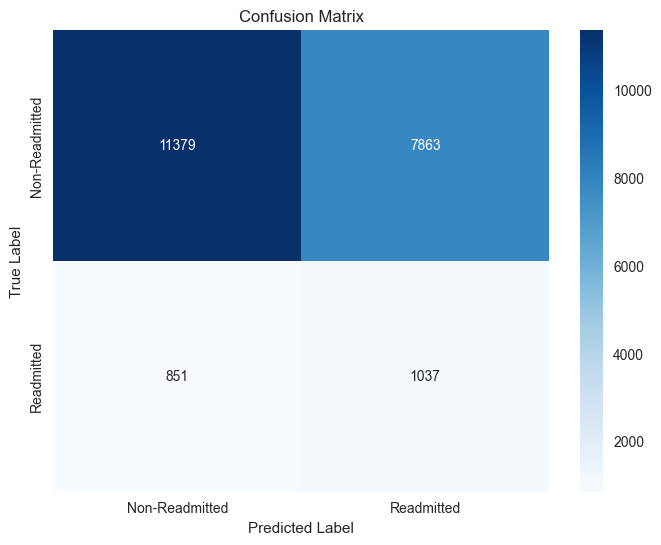

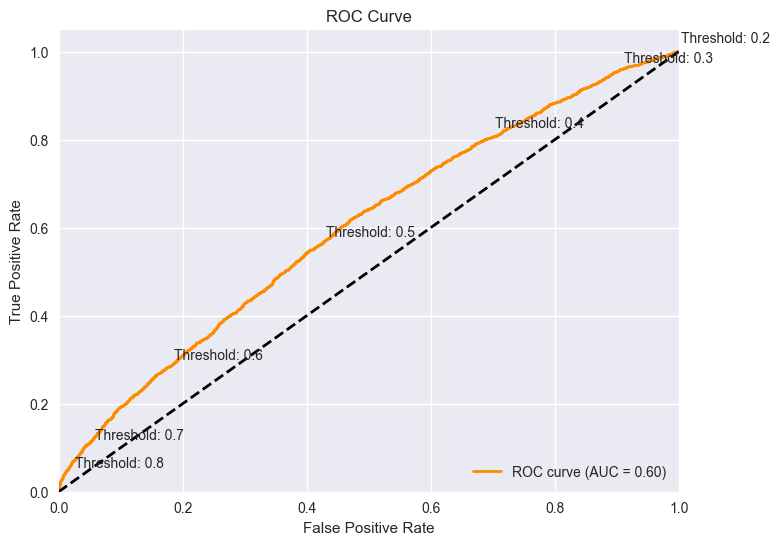

In [6]:
def train_and_evaluate_model(X_train, X_test, y_train, y_test, cv=5):
    """
    Trains the logistic regression model and evaluates its performance.
    """
    # Create and train model
    model = LogisticRegression(
        random_state=42,
        max_iter=1000, #let the model run 1000 times
        class_weight='balanced' #equal weightage in 0 and 1 , can give eg {0:0.6,1:0.4}
    )


    # Perform cross-validation
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc'
    )

    print("Cross-validation Results:")
    print(f"Mean ROC AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

    # Train final model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    # Print model equation
    print("\nLogistic Regression Equation:")
    print("===========================")
    print("log(p/(1-p)) = ", end="")

    # Print intercept
    print(f"{model.intercept_[0]:.3f}", end="")
    # Print each feature's coefficient
    for coef, feature in zip(model.coef_[0], X_train.columns):
        if coef >= 0:
            print(f" + {coef:.3f}*{feature}", end="")
        else:
            print(f" - {abs(coef):.3f}*{feature}", end="")
    print("\n")

    # Print classification report
    print("\nClassification Report:")
    print("=====================")
    print(classification_report(y_test, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Readmitted', 'Readmitted'],
        yticklabels=['Non-Readmitted', 'Readmitted']
    )
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange',
            lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    # Add threshold annotations
    threshold_points = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    for threshold in threshold_points:
        idx = np.argmin(np.abs(thresholds - threshold))
        plt.annotate(
            f'Threshold: {threshold:.1f}',
            (fpr[idx], tpr[idx]),
            xytext=(10, 10),
            textcoords='offset points'
        )

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return model, cv_scores

# Train and evaluate model
#model, cv_scores = train_and_evaluate_model(X_train, X_test, y_train, y_test)
model, cv_scores = train_and_evaluate_model(X_train_balanced, X_test, y_train_balanced, y_test)